<a href="https://colab.research.google.com/github/altafmadni/Data_Projects/blob/main/Chat_GPT_Analysis/Chatgpt_NewDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
url = "/content/chatgpt_reviews.csv"
df= pd.read_csv(url)

In [ ]:
df.head()

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [ ]:
df.columns

Index(['Review Id', 'Review', 'Ratings', 'Review Date'], dtype='object')

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.strip()

In [ ]:
df.isnull().sum()

,0
review_id,0
review,0
ratings,0
review_date,0


In [ ]:
df['review'].fillna(" ", inplace = True)

/tmp/ipykernel_1312/2195683206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna(" ", inplace = True)


In [ ]:
df.isna().sum()

,0
review_id,0
review,0
ratings,0
review_date,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   review_id    196727 non-null  object        
 1   review       196727 non-null  object        
 2   ratings      196727 non-null  int64         
 3   review_date  196727 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 6.0+ MB


In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   review_id    196727 non-null  object        
 1   review       196727 non-null  object        
 2   ratings      196727 non-null  int64         
 3   review_date  196727 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 6.0+ MB


## Sentiment Analysis


In [ ]:
def get_sentiment_polarity(text):
  if pd.isna(text) or text == "":
    return 0
  blob = TextBlob(text)
  return blob.sentiment.polarity

df['sentiment_polarity'] = df['review'].apply(get_sentiment_polarity)

In [ ]:
display(df.head())

,review_id,review,ratings,review_date,sentiment_polarity
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125


In [ ]:
def get_sentiment_category(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_polarity'].apply(get_sentiment_category)

In [ ]:
df.head()

,review_id,review,ratings,review_date,sentiment_polarity,sentiment_category
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000,Positive
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000,Positive
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000,Positive
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000,Positive
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125,Positive


In [ ]:
def get_sentiment_subjectivity(text):
  if pd.isna(text) or text == "":
    return 0
  blob = TextBlob(text)
  return blob.sentiment.subjectivity

df['sentiment_subjectivity'] = df['review'].apply(get_sentiment_subjectivity)

In [ ]:
df.head()

,review_id,review,ratings,review_date,sentiment_polarity,sentiment_category,sentiment_subjectivity
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000,Positive,0.600000
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000,Positive,0.600000
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000,Positive,1.000000
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000,Positive,1.000000
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125,Positive,0.542949


## Visualize Sentiment Analysis

In [ ]:
sentiment_counts

,count
sentiment_category,
Positive,145551
Neutral,44870
Negative,6306


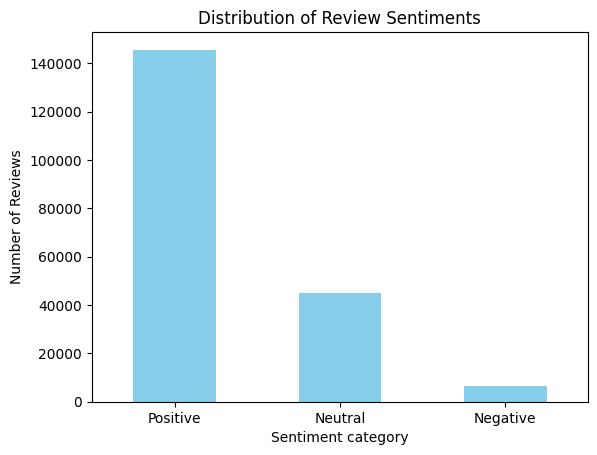

In [ ]:
sentiment_counts  = df['sentiment_category'].value_counts()

sentiment_counts.plot(kind = 'bar', color = 'skyblue')
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation = 0)
plt.show()


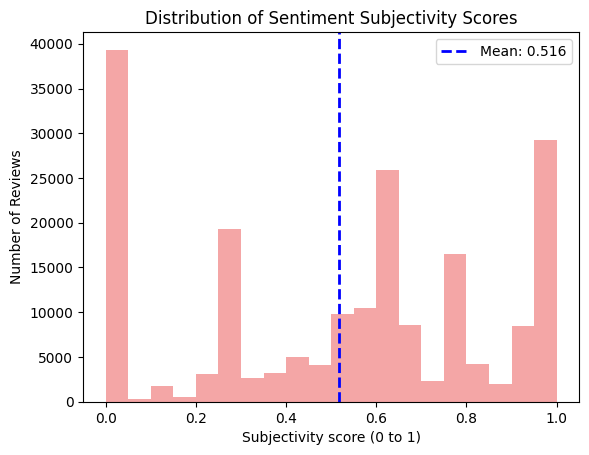

In [ ]:
plt.hist(df['sentiment_subjectivity'], bins = 20, color = 'lightcoral', alpha=0.7)
plt.axvline(df['sentiment_subjectivity'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {df['sentiment_subjectivity'].mean():.3f}')
plt.title('Distribution of Sentiment Subjectivity Scores')
plt.xlabel('Subjectivity score (0 to 1)')
plt.ylabel('Number of Reviews')
plt.legend()
plt.show()

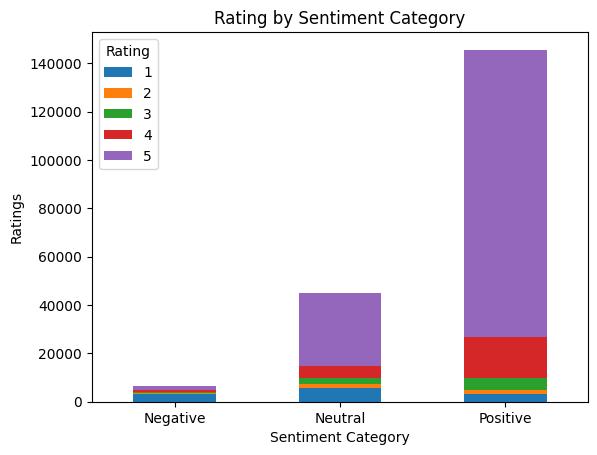

In [ ]:
sentiment_rating = df.groupby(['sentiment_category','ratings']).size().unstack(fill_value=0)
sentiment_rating.plot(kind  ='bar', stacked = True)
# plt.axvline(df['sentiment_subjectivity'].mean(), color='blue', linestyle='dashed', linewidth=2, label=f'Mean: {df['sentiment_subjectivity'].mean():.3f}')
plt.title('Rating by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.xticks(rotation = 0)
plt.ylabel('Ratings')
plt.legend(title = 'Rating', loc = 'upper left')
plt.show()

## Analyzing Positive Reviews

In [ ]:
positive_review = df[df['sentiment_category'] == 'Positive']['review']

In [ ]:
positive_review

,review
0,good
1,good
2,nice app
3,"nice, ig"
4,"this is a great app, the bot is so accurate to..."
...,...
196702,Super App
196704,First download
196711,very goid
196714,first review


In [ ]:
from collections import Counter
all_text = ' '.join(positive_review.astype(str)).lower()

# Clean text
cleaned_text = re.sub(r'[^a-zA-Z\s]', "", all_text)
words = cleaned_text.split()

# Remove all words whose length is < 3
words = [word for word in words if len(word) > 2]

# Get phrases(bigrams and trigrams)
phrases = []

for i in range(len(words) - 1):
  if len(words[i]) > 2 and len(words[i+1]) > 2:
    phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
  if all(len(word) > 2 for word in words[i:i+3]):
    phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

pos_phrases = phrase_freq.most_common(10)


In [ ]:
pos_phrases

[('this app', 10262),
 ('very good', 9334),
 ('the best', 6790),
 ('good app', 5799),
 ('very helpful', 5452),
 ('best app', 5407),
 ('app very', 4622),
 ('very useful', 4267),
 ('good good', 3959),
 ('very nice', 3495)]

## Visualize Positive Features

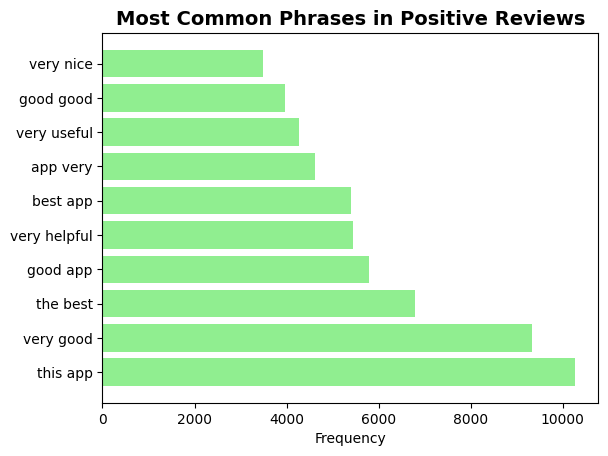

In [ ]:
phrases, phrase_counts = zip(*pos_phrases)

plt.barh(range(len(phrases)), phrase_counts, color='lightgreen')
plt.yticks(range(len(phrases)), phrases)

plt.title("Most Common Phrases in Positive Reviews", fontsize = 14, fontweight= 'bold')
plt.xlabel("Frequency")

plt.show()

## Analyzing Negative Reviews

In [ ]:
negative_review = df[df['sentiment_category'] == 'Negative']['review']

In [ ]:
negative_review

,review
10,I am not very happy with this because chatgpt ...
119,not good
134,Too expensive
176,"Correct answer Accuracy 10 %,always provide wr..."
222,"I get a ""something went wrong"" error so I can'..."
...,...
196145,Sucks
196617,random sjsj
196665,Not sure
196672,hands down


In [ ]:
from collections import Counter
all_text = ' '.join(negative_review.astype(str)).lower()

# Clean text
cleaned_text = re.sub(r'[^a-zA-Z\s]', "", all_text)
words = cleaned_text.split()

# Remove all words whose length is < 3
words = [word for word in words if len(word) > 2]

# Get phrases(bigrams and trigrams)
phrases = []

for i in range(len(words) - 1):
  if len(words[i]) > 2 and len(words[i+1]) > 2:
    phrases.append(f"{words[i]} {words[i+1]}")

for i in range(len(words) - 2):
  if all(len(word) > 2 for word in words[i:i+3]):
    phrases.append(f"{words[i]} {words[i+1]} {words[i+2]}")

phrase_freq = Counter(phrases)

neg_phrases = phrase_freq.most_common(10)


In [ ]:
neg_phrases

[('this app', 548),
 ('the app', 402),
 ('very bad', 259),
 ('not good', 171),
 ('chat gpt', 133),
 ('worst app', 129),
 ('bad app', 114),
 ('wrong answer', 108),
 ('its not', 105),
 ('with the', 99)]

## Visualize Negative Reviews


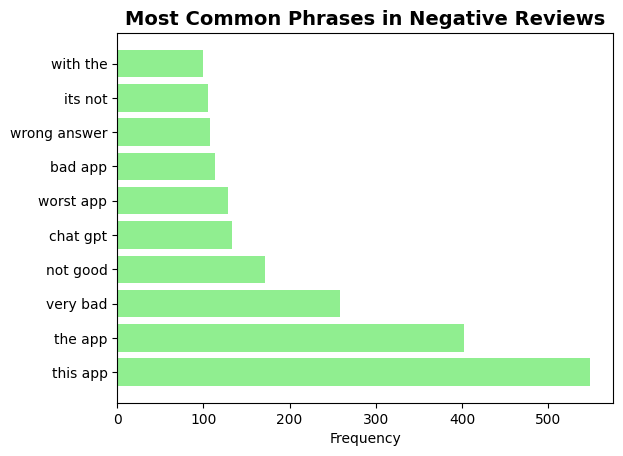

In [ ]:
phrases, phrase_counts = zip(*neg_phrases)

plt.barh(range(len(phrases)), phrase_counts, color='lightgreen')
plt.yticks(range(len(phrases)), phrases)

plt.title("Most Common Phrases in Negative Reviews", fontsize = 14, fontweight= 'bold')
plt.xlabel("Frequency")

plt.show()

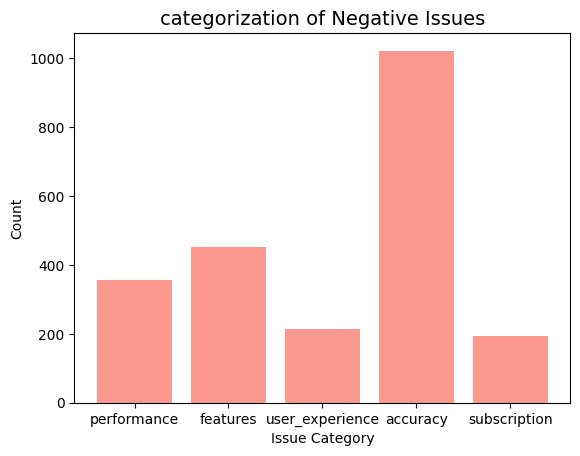

In [ ]:
issue_category = {

    "performance": [
        "slow",
        "lag",
        "loading",
        "crash",
        "freeze",
        "delay",
        "buffering",
        "timeout",
        "heating",
        "speed"
    ],

    "features": [
        "voice",
        "image",
        "coding",
        "writing",
        "translation",
        "research",
        "history",
        "search",
        "upload",
        "memory"
    ],

    "user_experience": [
        "interface",
        "design",
        "navigation",
        "layout",
        "simple",
        "friendly",
        "smooth",
        "confusing",
        "responsive",
        "experience"
    ],

    "accuracy": [
        "accurate",
        "incorrect",
        "wrong",
        "error",
        "mistake",
        "hallucination",
        "repetitive",
        "outdated",
        "reliable",
        "relevant"
    ],

    "subscription": [
        "premium",
        "subscription",
        "pricing",
        "payment",
        "refund",
        "billing",
        "renewal",
        "upgrade",
        "trial",
        "expensive"
    ]
}

category_counts = {}

for category, keywords in issue_category.items():
  count = 0
  for  review in negative_review:
    if any(keyword in str(review).lower() for keyword in keywords):
      count += 1
    category_counts[category] = count
categories = list(category_counts.keys())
counts = list(category_counts.values())

plt.bar(categories, counts, color ='salmon', alpha = 0.8)
plt.title('categorization of Negative Issues', fontsize = 14)
plt.xlabel('Issue Category')
plt.ylabel('Count')
plt.show()

## Analyzing Neutral Reviews

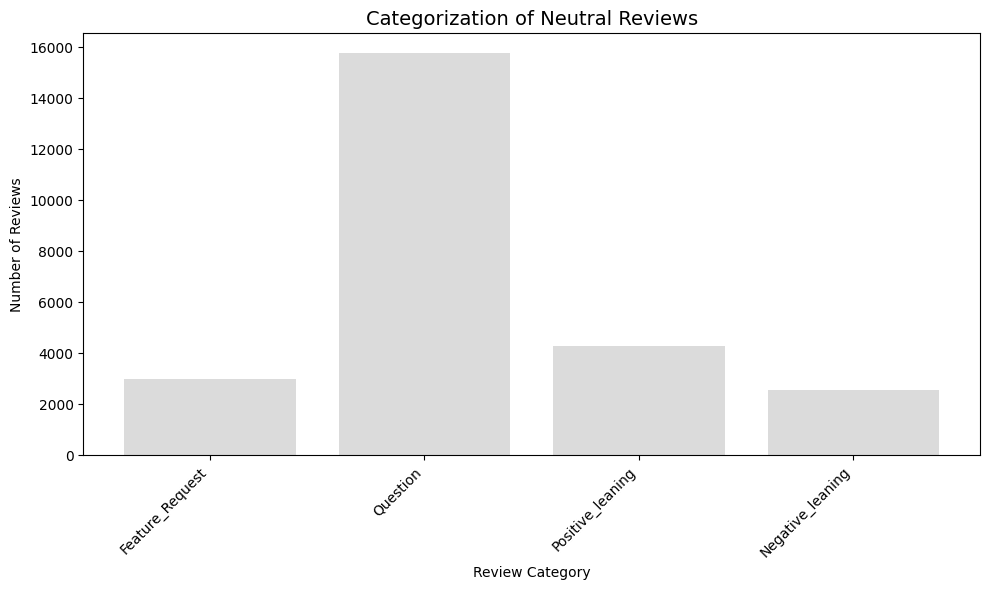

In [ ]:
keyword_map = {

    "Feature_Request": [
        "add",
        "include",
        "support",
        "feature",
        "option",
        "allow",
        "provide",
        "implement",
        "improve",
        "update"
    ],

    "Question": [
        "how",
        "why",
        "when",
        "where",
        "what",
        "can",
        "does",
        "is",
        "unable",
        "help"
    ],

    "Positive_leaning": [
        "good",
        "nice",
        "decent",
        "useful",
        "helpful",
        "easy",
        "better",
        "impressive",
        "smooth",
        "satisfied"
    ],

    "Negative_leaning": [
        "slow",
        "bug",
        "issue",
        "error",
        "problem",
        "wrong",
        "poor",
        "difficult",
        "confusing",
        "limited"
    ]
}

# Redefine neutral_review as the previous cell was deleted
neutral_review = df[df['sentiment_category'] == 'Neutral']['review']

neutral_category_counts = {}

for category, keywords in keyword_map.items():
  count = 0
  # Iterate directly over neutral_review (which is already a Series of review texts)
  for review_text in neutral_review:
    if any(keyword in str(review_text).lower() for keyword in keywords):
      count += 1
  neutral_category_counts[category] = count

categories_for_plot = list(neutral_category_counts.keys())
counts_for_plot = list(neutral_category_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(categories_for_plot, counts_for_plot, color='lightgray', alpha=0.8)
plt.title('Categorization of Neutral Reviews', fontsize=14)
plt.xlabel('Review Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Review Evolution over Time


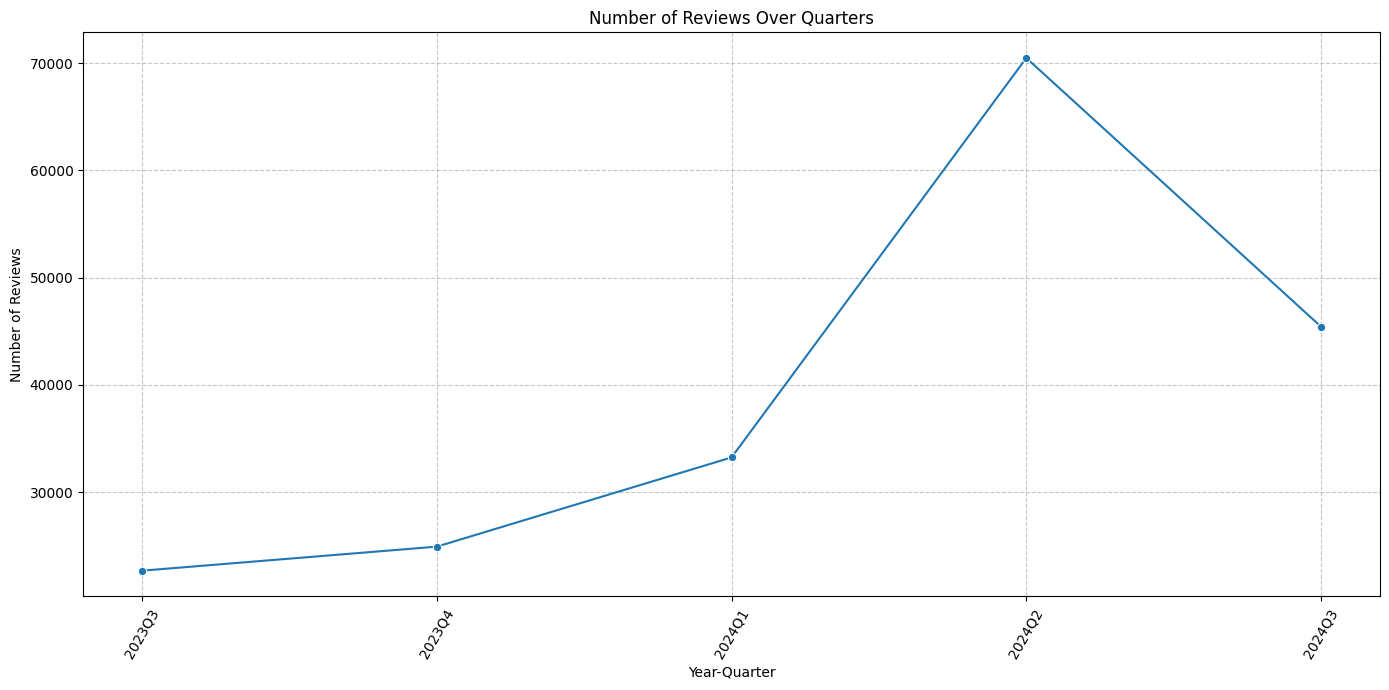

In [ ]:
df['year_quarter'] = df['review_date'].dt.to_period('Q')

# Calculate the number of reviews per quarter
reviews_over_quarter = df.groupby('year_quarter').size().reset_index(name='number_of_reviews')

reviews_over_quarter['year_quarter'] = reviews_over_quarter['year_quarter'].astype(str)

plt.figure(figsize=(14, 7))
sns.lineplot(x='year_quarter', y='number_of_reviews', data=reviews_over_quarter, marker='o')
plt.title('Number of Reviews Over Quarters')
plt.xlabel('Year-Quarter')
plt.ylabel('Number of Reviews')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

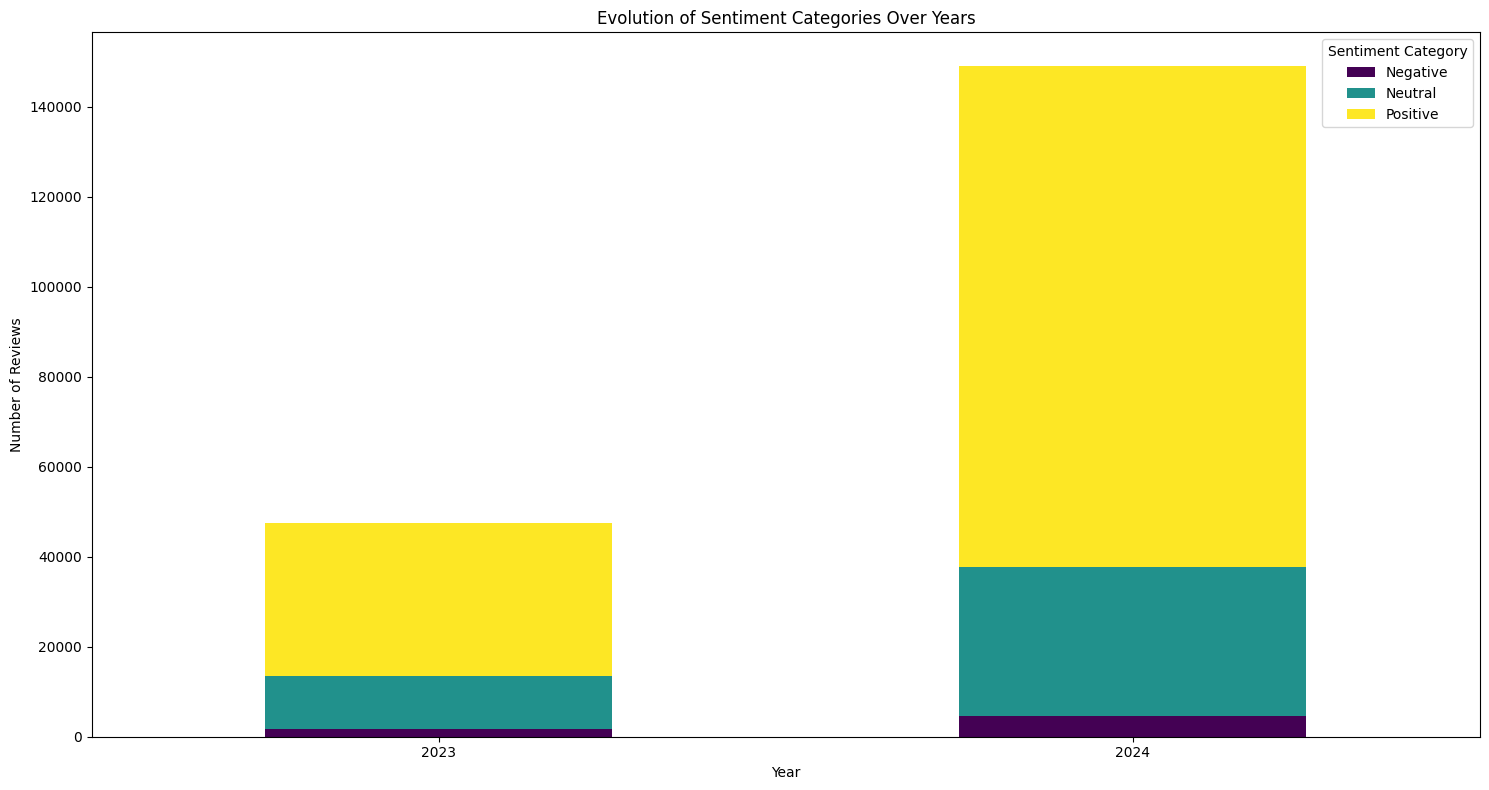

In [ ]:
df['year'] = df['review_date'].dt.year

sentiment_category_over_year = df.groupby(['year', 'sentiment_category']).size().unstack(fill_value=0)

# Plotting a stacked bar chart to show the evolution of sentiment categories per year
sentiment_category_over_year[['Negative', 'Neutral', 'Positive']].plot(kind='bar', stacked=True, figsize=(15, 8), colormap='viridis')
plt.title('Evolution of Sentiment Categories Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment Category')
plt.tight_layout()
plt.show()